# Descriptors distance as a function of the distance of an atop atom from graphene 

In [61]:
from mace.calculators import MACECalculator
from ase.build import graphene
from ase.visualize import view
from ase import Atom, Atoms
import numpy as np

from tqdm import tqdm

import math
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
import matplotlib.colors as colors

In [2]:
calc = MACECalculator("MACE.model", device="cuda")

/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


## Some testing

The descriptors can be accessed using calc.get_descriptors() with appropriate parameters

In [39]:
atoms = graphene()
atoms = atoms.repeat((5,5,1))

atoms.append(Atom("C", (0, 0, 2.5)))
atoms.pop(-1)

Atom('C', [np.float64(0.0), np.float64(0.0), np.float64(2.5)])

In [40]:
atoms.positions

array([[ 0.        ,  0.        ,  0.        ],
       [ 1.23      ,  0.71014083,  0.        ],
       [-1.23      ,  2.13042249,  0.        ],
       [ 0.        ,  2.84056332,  0.        ],
       [-2.46      ,  4.26084499,  0.        ],
       [-1.23      ,  4.97098582,  0.        ],
       [-3.69      ,  6.39126748,  0.        ],
       [-2.46      ,  7.10140831,  0.        ],
       [-4.92      ,  8.52168997,  0.        ],
       [-3.69      ,  9.2318308 ,  0.        ],
       [ 2.46      ,  0.        ,  0.        ],
       [ 3.69      ,  0.71014083,  0.        ],
       [ 1.23      ,  2.13042249,  0.        ],
       [ 2.46      ,  2.84056332,  0.        ],
       [ 0.        ,  4.26084499,  0.        ],
       [ 1.23      ,  4.97098582,  0.        ],
       [-1.23      ,  6.39126748,  0.        ],
       [ 0.        ,  7.10140831,  0.        ],
       [-2.46      ,  8.52168997,  0.        ],
       [-1.23      ,  9.2318308 ,  0.        ],
       [ 4.92      ,  0.        ,  0.   

In [41]:
view(atoms, viewer="x3d")

In [33]:
atoms.calc=calc
e=atoms.get_potential_energy()
fs=atoms.get_forces()
stress=atoms.get_stress()

In [35]:
descriptors = calc.get_descriptors(num_layers=1)
descriptors.shape

(51, 128)

In [38]:
hs = np.linspace(0.8, 6, num=100)

## Proper evaluation of descriptors distances

### loop over distances

In [42]:
descriptors = []
energies = []
forces = []
stresses = []

atoms = graphene()
atoms = atoms.repeat((5,5,1))
atoms.calc = calc

for h in hs:
    new_atom = Atom("C", position=(0,0,h))
    atoms.append(new_atom)

    e = atoms.get_potential_energy()
    fs = atoms.get_forces()
    stress = atoms.get_stress()

    desc = calc.get_descriptors(atoms = atoms, num_layers=1)

    energies.append(e)
    forces.append(fs)
    stresses.append(stress)

    descriptors.append(desc)

    atoms.pop(-1)

### some manipulations of descriptors and lists

In [86]:
descriptors = np.array(descriptors)
descriptors.shape

energies = np.array(energies)
forces = np.array(forces)
stresses = np.array(stresses)

In [75]:
# will only consider the descriptors of the last atom, this is always appended and removed, is the adatom at varying distance

descriptors[:,-1].shape

(100, 128)

### build distance metrics, choose some function from there

In [ ]:
dist_matrix = cdist(descriptors[:,-1], descriptors[:,-1], metric='euclidean')

In [81]:
kernel_matrix = np.exp(-dist_matrix**(1))

Text(0, 0.5, 'A')

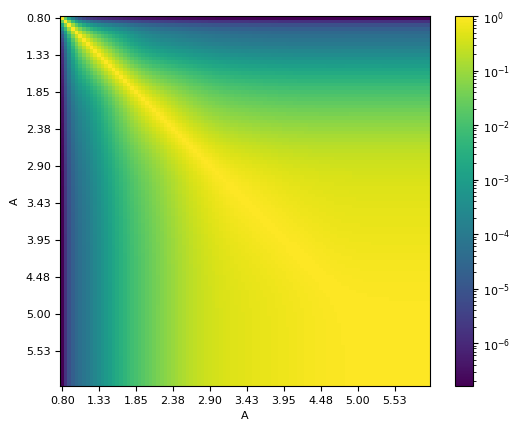

In [83]:
plt.imshow(kernel_matrix, norm=colors.LogNorm(vmin=kernel_matrix.min(), vmax=kernel_matrix.max()))
plt.colorbar()

ticks = hs[::10]
labels = [f"{t:.2f}" for t in ticks]
indices = np.arange(0, 100, 10)
plt.xticks(indices, labels);
plt.yticks(indices, labels);
plt.xlabel("A")
plt.ylabel("A")

Text(0, 0.5, 'Energy [eV/atom]')

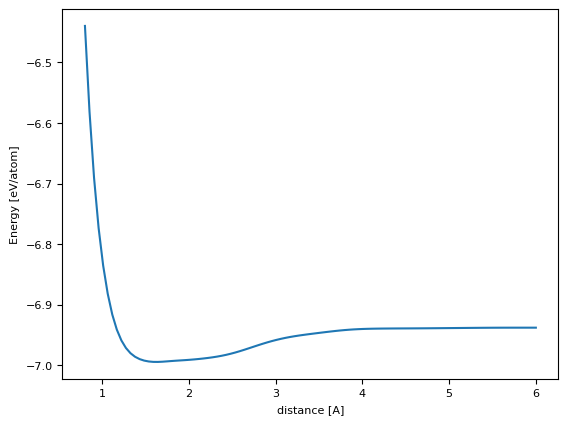

In [87]:
plt.plot(hs, energies/len(atoms) + 1) # at the end, the adatom is removed, but must be counted!

plt.xlabel("distance [A]")
plt.ylabel("Energy [eV/atom]")

Text(0, 0.5, 'descriptors vector norm')

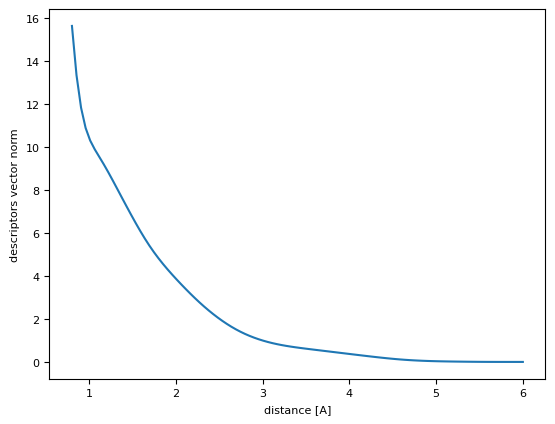

In [92]:
plt.plot(hs, np.linalg.norm(descriptors[:,-1], axis=-1));
plt.xlabel("distance [A]")
plt.ylabel("descriptors vector norm")
